# Scikit-learn in Pratica

In questa lezione "metteremo in pratica" le cose apprese in precedenza.
In particolare vederemo come si utilizza il modulo/libreria di Python chiamata Scikit-Learn.

La utilizzeremo per realizzare una classificazione utizzando i  DecisionTree e poi applicheremo:   Confusion Matrix, AUC-ROC, Accuracy


##  Cos'è Scikit-learn?

**Scikit-learn** è la libreria Python standard per il Machine Learning classico.
Segue sempre la stessa interfaccia a tre metodi:

```python
model.fit(X_train, y_train)      # addestra il modello
model.predict(X_test)            # predice le etichette
model.predict_proba(X_test)      # predice le probabilità (se disponibile)
```

Ogni modello è un oggetto Python — si crea, si addestra, si usa. Sempre uguale, indipendentemente dall'algoritmo.


**N.B.**
Lo utilizzeremo con il classificatore Decision Tree ma l'approccio ad oggetti varrà per qualunque modello.



---

##  Dataset di Esempio


In questa eserciztazione useremo un dataset molto noto:  il classico dataset **Breast Cancer** (classificazione binaria: tumore maligno vs benigno):


```python
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
import pandas as pd

# Carica il dataset
data = load_breast_cancer()
X = data.data          # 569 campioni, 30 feature numeriche
y = data.target        # 0 = maligno, 1 = benigno

# Stampa info
print(f"Dimensione dataset: {X.shape}")
print(f"Classi: {data.target_names}")   # ['malignant' 'benign']
print(f"Distribuzione classi: {pd.Series(y).value_counts().to_dict()}")

# Split train/test: 80% training, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,       # riproducibilità
    stratify=y             # mantiene la proporzione delle classi
)

print(f"Train: {X_train.shape[0]} campioni")
print(f"Test:  {X_test.shape[0]} campioni")
```

---

## Decision Tree


Ripasso "teoria":
Come visto nelle lezioni precedenti, un **Decision Tree** suddivide ricorsivamente lo spazio delle variabili (feature nel linguaggio del machine learning) con regole del tipo:

$$\text{if } x_j \leq t \text{ then vai a sinistra, else vai a destra}$$

Ad ogni nodo, la soglia $t$ e la feature $j$ vengono scelte minimizzando l'**impurità di Gini**:

$$G = \sum_{k=1}^{K} p_k(1 - p_k) = 1 - \sum_{k=1}^{K} p_k^2$$

oppure l'**entropia**:

$$H = -\sum_{k=1}^{K} p_k \log_2 p_k$$

dove $p_k$ è la frazione di campioni della classe $k$ nel nodo. Il guadagno informativo di uno split è:

$$\text{IG} = \text{impurità(parent)} - \frac{n_L}{n}\,\text{impurità(left)} - \frac{n_R}{n}\,\text{impurità(right)}$$



###  Addestramento con Scikit-learn

Vediamo come si addestra un modello con Scikit-learn


```python
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# Crea il modello
# max_depth controlla la complessità → trade-off Bias-Varianza
dt = DecisionTreeClassifier(
    max_depth=4,           # profondità massima dell'albero
    criterion='gini',      # impurità di Gini (alternativa: 'entropy')
    min_samples_leaf=5,    # almeno 5 campioni per foglia (regolarizzazione)
    random_state=42
)

# Addestramento
dt.fit(X_train, y_train)

# Predizione
y_pred = dt.predict(X_test)
y_proba = dt.predict_proba(X_test)[:, 1]  # probabilità della classe positiva (1 = benigno)

print("Prime 5 predizioni:", y_pred[:5])
print("Prime 5 probabilità:", y_proba[:5].round(3))
```

###  Visualizzazione dell'Albero

I decision tree sono modelli "semplici" che hanno il vantaggio di essere interpretabili visivamente


```python
plt.figure(figsize=(20, 8))
plot_tree(
    dt,
    feature_names=data.feature_names,
    class_names=data.target_names,
    filled=True,          # colora i nodi per classe
    rounded=True,
    fontsize=9
)
plt.title("Decision Tree (max_depth=4)", fontsize=14)
plt.tight_layout()
plt.show()
```

###  Feature Importance o importanza delle variabili

L'importanza delle variabili
```python
import numpy as np

importances = dt.feature_importances_
indices = np.argsort(importances)[::-1][:10]  # top 10

plt.figure(figsize=(10, 5))
plt.bar(range(10), importances[indices], color='steelblue')
plt.xticks(range(10), data.feature_names[indices], rotation=45, ha='right')
plt.title("Top 10 Feature Importance")
plt.ylabel("Gini Importance")
plt.tight_layout()
plt.show()
```

---

## Accuracy


Ricordiamo che l'**accuracy** è la metrica più semplice: frazione di predizioni corrette sul totale.

$$\text{Accuracy} = \frac{\text{predizioni corrette}}{\text{totale campioni}} = \frac{TP + TN}{TP + TN + FP + FN}$$

dove:
- $TP$ = True Positive (positivo predetto correttamente)
- $TN$ = True Negative (negativo predetto correttamente)
- $FP$ = False Positive (negativo classificato come positivo)
- $FN$ = False Negative (positivo classificato come negativo)

### Limiti dell'Accuracy

 Su dataset **sbilanciati** l'accuracy è ingannevole. Se il 95% dei campioni è della classe 0, un modello che predice sempre 0 ha accuracy = 95% ma è inutile.

###  Calcolo con Scikit-learn
```python
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}  ({acc*100:.2f}%)")
```

---

##  Confusion Matrix


La **Confusion Matrix** è una tabella $K \times K$ (con $K$ = numero di classi) che mostra quante volte ogni classe è stata predetta come ogni altra classe:

$$
\mathbf{C} = \begin{pmatrix} TN & FP \\ FN & TP \end{pmatrix}
\quad \text{(caso binario)}
$$

|  | Predetto: Negativo | Predetto: Positivo |
|---|---|---|
| **Reale: Negativo** | $TN$ | $FP$ |
| **Reale: Positivo** | $FN$ | $TP$ |

Da essa derivano tutte le metriche principali:

$$\text{Precision} = \frac{TP}{TP + FP}$$

$$\text{Recall (Sensitivity)} = \frac{TP}{TP + FN}$$

$$\text{F1-Score} = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$$

$$\text{Specificity} = \frac{TN}{TN + FP}$$

### Calcolo e Visualizzazione con Scikit-learn

Vediamo quindi come calcolare quanto visto teoricamente con la libreria Scikit-learn.


```python
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

# Matrice di confusione
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Visualizzazione grafica
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title("Confusion Matrix — Decision Tree")
plt.tight_layout()
plt.show()

# Report completo: precision, recall, f1 per ogni classe
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=data.target_names))
```

### Lettura del Classification Report


Inseriamo qui di seguito un esempio di Report e sua analisi

```
              precision    recall  f1-score   support

   malignant       0.95      0.90      0.92        42
      benign       0.95      0.97      0.96        72

    accuracy                           0.95       114
   macro avg       0.95      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114
```

Domande tipiche su cui ragionare:

- **precision**: su tutti i campioni predetti come classe X, quanti lo erano davvero?
- **recall**: su tutti i campioni reali della classe X, quanti ho recuperato?
- **support**: numero di campioni reali per classe nel test set
- **macro avg**: media non pesata tra le classi
- **weighted avg**: media pesata per il numero di campioni

---

## AUC-ROC

Riprendiamo la parte teorica ricordando cosa è la curva ROC e l'area sotto la curva roc (AUC-ROC).


###  La Curva ROC

La **ROC (Receiver Operating Characteristic)** curve mostra il trade-off tra:

$$\text{True Positive Rate (TPR)} = \text{Recall} = \frac{TP}{TP + FN}$$

$$\text{False Positive Rate (FPR)} = \frac{FP}{FP + TN}$$

al variare della **soglia di classificazione** $\tau \in [0, 1]$:

$$\hat{y} = \begin{cases} 1 & \text{se } \hat{p}(x) \geq \tau \\ 0 & \text{se } \hat{p}(x) < \tau \end{cases}$$

Per $\tau = 1$: nessun positivo predetto → TPR = 0, FPR = 0 (angolo in basso a sinistra)
Per $\tau = 0$: tutti predetti positivi → TPR = 1, FPR = 1 (angolo in alto a destra)

La curva ROC traccia il percorso da $(0,0)$ a $(1,1)$ al diminuire di $\tau$.

###  AUC: Area Under the Curve

$$\text{AUC} = \int_0^1 \text{TPR}(\text{FPR})\, d(\text{FPR})$$


Normalmente viene calcolate stimando l'area con metodi numerici (approssimazione metodo dei rettangoli o dei trapezi visto in precedenti lezioni).

Interpretazione probabilistica:

$$\text{AUC} = P\left(\hat{p}(x^+) > \hat{p}(x^-)\right)$$

**Un modello con AUC = 0.95 classifica correttamente l'ordine tra un campione positivo e uno negativo nel 95% dei casi.**

| AUC | Interpretazione |
|---|---|
| $= 0.5$ | Modello casuale (diagonale) |
| $0.7 - 0.8$ | Discreto |
| $0.8 - 0.9$ | Buono |
| $0.9 - 1.0$ | Ottimo |
| $= 1.0$ | Perfetto (attenzione: possibile overfitting) |

### Calcolo e Visualizzazione con Scikit-learn

Vediamo come applicarlo con Scikit-learn.

```python
from sklearn.metrics import roc_curve, roc_auc_score, RocCurveDisplay

# AUC score (richiede le probabilità, non le classi predette)
auc = roc_auc_score(y_test, y_proba)
print(f"AUC-ROC: {auc:.4f}")

# Curva ROC completa
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

# Visualizzazione
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color='steelblue', lw=2,
        label=f'Decision Tree (AUC = {auc:.3f})')
ax.plot([0, 1], [0, 1], color='gray', lw=1,
        linestyle='--', label='Classificatore casuale (AUC = 0.5)')
ax.fill_between(fpr, tpr, alpha=0.1, color='steelblue')  # area sotto la curva
ax.set_xlabel("False Positive Rate (FPR)", fontsize=12)
ax.set_ylabel("True Positive Rate (TPR)", fontsize=12)
ax.set_title("ROC Curve — Decision Tree", fontsize=14)
ax.legend(loc='lower right', fontsize=11)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.show()
```

### Come  trovare la Soglia Ottimale (Youden Index)

E' possibile fare un ulteriore ragionamento sulla soglia ottimale per classificare.


```python
# Il punto della curva ROC più lontano dalla diagonale
youden_index = tpr - fpr
optimal_idx = np.argmax(youden_index)
optimal_threshold = thresholds[optimal_idx]

print(f"Soglia ottimale (Youden):  τ = {optimal_threshold:.3f}")
print(f"  → TPR = {tpr[optimal_idx]:.3f}")
print(f"  → FPR = {fpr[optimal_idx]:.3f}")

# Evidenzia il punto ottimale sulla curva
ax.scatter(fpr[optimal_idx], tpr[optimal_idx],
           color='red', s=100, zorder=5,
           label=f'Soglia ottimale τ={optimal_threshold:.2f}')
```

---

## 7. Confronto: Accuracy vs AUC-ROC
```python
# Confronto tra soglia di default (0.5) e soglia ottimale
from sklearn.metrics import accuracy_score

# Soglia standard 0.5
y_pred_05 = (y_proba >= 0.5).astype(int)
acc_05 = accuracy_score(y_test, y_pred_05)

# Soglia ottimale (Youden)
y_pred_opt = (y_proba >= optimal_threshold).astype(int)
acc_opt = accuracy_score(y_test, y_pred_opt)

print(f"Accuracy con τ=0.50:            {acc_05:.4f}")
print(f"Accuracy con τ={optimal_threshold:.2f} (ottimale): {acc_opt:.4f}")
print(f"AUC-ROC (invariante alla soglia): {auc:.4f}")
```

| Metrica | Dipende dalla soglia $\tau$? | Utile quando |
|---|---|---|
| **Accuracy** | Sì | Classi bilanciate |
| **Precision / Recall** |  Sì | Classi sbilanciate, costi asimmetrici |
| **F1-Score** |  Sì | Bilanciamento precision-recall |
| **AUC-ROC** |  No | Confronto generale tra modelli |

---

##  Pipeline Completa in 20 Righe
```python
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             ConfusionMatrixDisplay, roc_auc_score)
import matplotlib.pyplot as plt

# Dati
X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Modello
dt = DecisionTreeClassifier(max_depth=4, random_state=42)
dt.fit(X_train, y_train)

# Metriche
y_pred  = dt.predict(X_test)
y_proba = dt.predict_proba(X_test)[:, 1]

print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"AUC-ROC  : {roc_auc_score(y_test, y_proba):.4f}")

# Confusion Matrix
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred),
    display_labels=['maligno','benigno']).plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()
```

---

## Riepilogo

| Strumento | Funzione Scikit-learn | Input richiesto |
|---|---|---|
| **Decision Tree** | `DecisionTreeClassifier` | `X_train, y_train` |
| **Predizione classi** | `.predict(X_test)` | features test |
| **Predizione probabilità** | `.predict_proba(X_test)` | features test |
| **Accuracy** | `accuracy_score(y, ŷ)` | classi vere e predette |
| **Confusion Matrix** | `confusion_matrix(y, ŷ)` | classi vere e predette |
| **Report completo** | `classification_report(y, ŷ)` | classi vere e predette |
| **AUC-ROC** | `roc_auc_score(y, p̂)` | classi vere e **probabilità** |
| **Curva ROC** | `roc_curve(y, p̂)` | classi vere e **probabilità** |

>  **Regola d'oro:** `accuracy_score` e `confusion_matrix` vogliono le **classi predette** (`predict`).
> `roc_auc_score` e `roc_curve` vogliono le **probabilità** (`predict_proba[:, 1]`).

In [10]:

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
import pandas as pd

# Carica il dataset
data = load_breast_cancer()
X = data.data          # 569 campioni, 30 feature numeriche
y = data.target        # 0 = maligno, 1 = benigno

# Stampa info
print(f"Dimensione dataset: {X.shape}")
print(f"Classi: {data.target_names}")   # ['malignant' 'benign']
print(f"Distribuzione classi: {pd.Series(y).value_counts().to_dict()}")

# Split train/test: 80% training, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,       # riproducibilità
    stratify=y             # mantiene la proporzione delle classi
)

print(f"Train: {X_train.shape[0]} campioni")
print(f"Test:  {X_test.shape[0]} campioni")



Dimensione dataset: (569, 30)
Classi: ['malignant' 'benign']
Distribuzione classi: {1: 357, 0: 212}
Train: 455 campioni
Test:  114 campioni


In [11]:
# stampa per capire tipo di dato:
print(type(X))

<class 'numpy.ndarray'>


In [12]:
590*0.20

118.0

In [13]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# Crea il modello
# max_depth controlla la complessità → trade-off Bias-Varianza
dt = DecisionTreeClassifier(
    max_depth=2,           # profondità massima dell'albero
    criterion='gini',      # impurità di Gini (alternativa: 'entropy')
    min_samples_leaf=5,    # almeno 5 campioni per foglia (regolarizzazione)
    random_state=42
)

# Addestramento
dt.fit(X_train, y_train)

# Predizione
y_pred = dt.predict(X_test)
y_proba = dt.predict_proba(X_test)[:, 1]  # probabilità della classe positiva (1 = benigno)

print("Prime 5 predizioni:", y_pred[:5])
print("Prime 5 probabilità:", y_proba[:5].round(3))

print(type(dt))

print(X_test.shape)
print(y_pred.shape)

Prime 5 predizioni: [0 1 0 0 0]
Prime 5 probabilità: [0.021 0.982 0.333 0.021 0.021]
<class 'sklearn.tree._classes.DecisionTreeClassifier'>
(114, 30)
(114,)


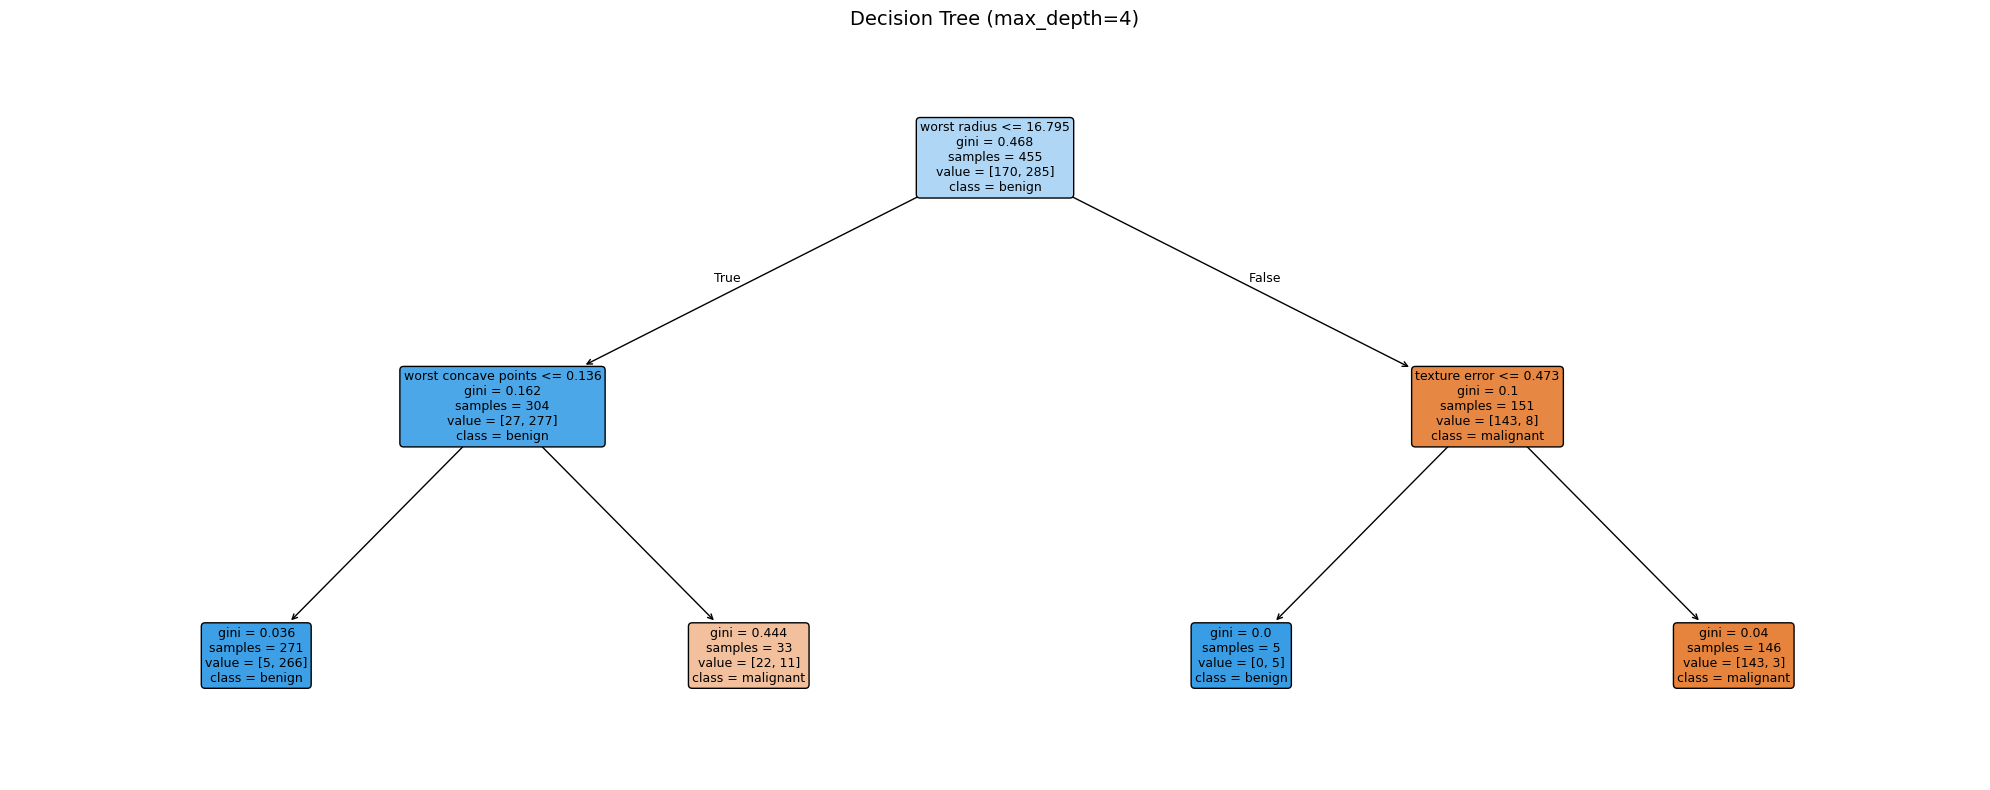

In [14]:
###  Visualizzazione dell'Albero
plt.figure(figsize=(20, 8))
plot_tree(
    dt,
    feature_names=data.feature_names,
    class_names=data.target_names,
    filled=True,          # colora i nodi per classe
    rounded=True,
    fontsize=9
)
plt.title("Decision Tree (max_depth=4)", fontsize=14)
plt.tight_layout()
plt.show()

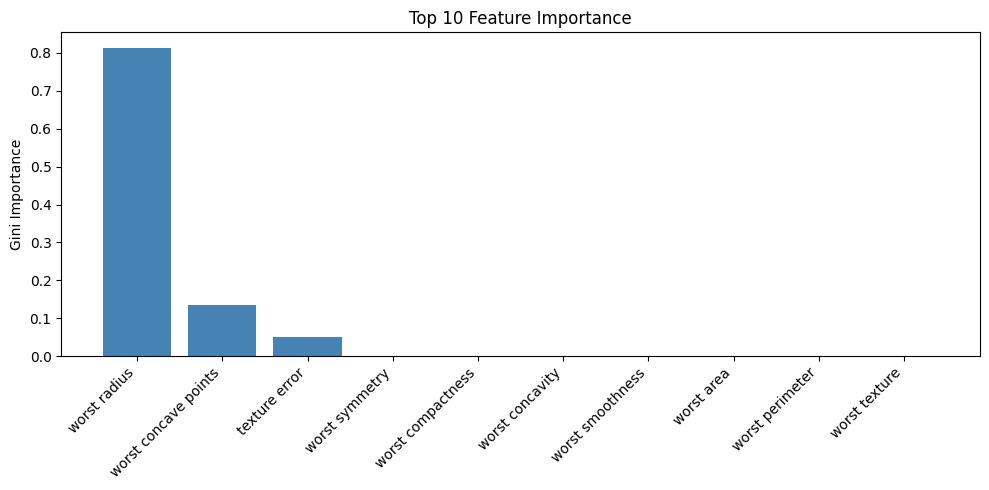

In [15]:
# questa parte è importante soprattutto quando
# il modello non è interpretabile
# vedremo dei cenni sul problema dell'interpretabilità dei modelli di ML
# che sono delle black box


import numpy as np

importances = dt.feature_importances_
indices = np.argsort(importances)[::-1][:10]  # top 10

plt.figure(figsize=(10, 5))
plt.bar(range(10), importances[indices], color='steelblue')
plt.xticks(range(10), data.feature_names[indices], rotation=45, ha='right')
plt.title("Top 10 Feature Importance")
plt.ylabel("Gini Importance")
plt.tight_layout()
plt.show()






Accuracy: 0.8947  (89.47%)
Confusion Matrix:
 [[40  2]
 [10 62]]


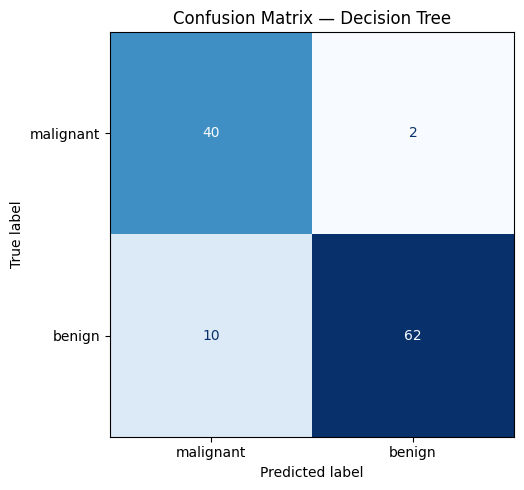


Classification Report:
              precision    recall  f1-score   support

   malignant       0.80      0.95      0.87        42
      benign       0.97      0.86      0.91        72

    accuracy                           0.89       114
   macro avg       0.88      0.91      0.89       114
weighted avg       0.91      0.89      0.90       114



In [16]:
## Accuracy

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt


acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}  ({acc*100:.2f}%)")


##  Confusion Matrix
# Matrice di confusione
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Visualizzazione grafica
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title("Confusion Matrix — Decision Tree")
plt.tight_layout()
plt.show()

# Report completo: precision, recall, f1 per ogni classe
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=data.target_names))


Accuracy : 0.9386
AUC-ROC  : 0.9342


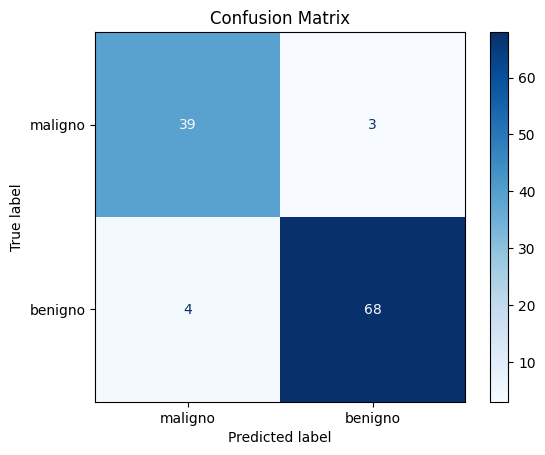

In [17]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             ConfusionMatrixDisplay, roc_auc_score)
import matplotlib.pyplot as plt

# Dati
X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Modello
dt = DecisionTreeClassifier(max_depth=4, random_state=42)
dt.fit(X_train, y_train)

# Metriche
y_pred  = dt.predict(X_test)
y_proba = dt.predict_proba(X_test)[:, 1]

print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"AUC-ROC  : {roc_auc_score(y_test, y_proba):.4f}")

# Confusion Matrix
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred),
    display_labels=['maligno','benigno']).plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

# Vediamo anche l'area sotto la curva


....
















AUC-ROC: 0.9342


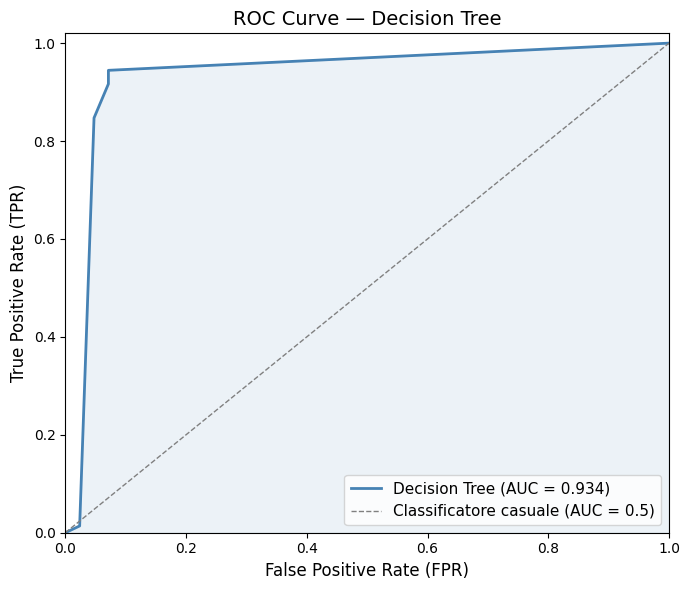

In [18]:
from sklearn.metrics import roc_curve, roc_auc_score, RocCurveDisplay

# AUC score (richiede le probabilità, non le classi predette)
auc = roc_auc_score(y_test, y_proba)
print(f"AUC-ROC: {auc:.4f}")

# Curva ROC completa
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

# Visualizzazione
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color='steelblue', lw=2,
        label=f'Decision Tree (AUC = {auc:.3f})')
ax.plot([0, 1], [0, 1], color='gray', lw=1,
        linestyle='--', label='Classificatore casuale (AUC = 0.5)')
ax.fill_between(fpr, tpr, alpha=0.1, color='steelblue')  # area sotto la curva
ax.set_xlabel("False Positive Rate (FPR)", fontsize=12)
ax.set_ylabel("True Positive Rate (TPR)", fontsize=12)
ax.set_title("ROC Curve — Decision Tree", fontsize=14)
ax.legend(loc='lower right', fontsize=11)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.show()


#

# Nella prossima lezione vedremo...

 Nella prossima lezione vedremo gli "esemble" ovvero insiemi di classificatori
